In [1]:
import numpy as np
import pandas as pd
import os
import cv2
from PIL import Image
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader, Subset, Dataset
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm
import random
import matplotlib.pyplot as plt


In [2]:
#路徑處理

train_dir = "xray_data/train"
test_dir  = "xray_data/test"

print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

print("Train classes:", os.listdir(train_dir)[:15])
print("Test samples:", os.listdir(test_dir)[:10])

Train exists: True
Test exists: True
Train classes: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Test samples: ['0.jpg', '1.jpg', '10.jpg', '100.jpg', '1000.jpg', '1001.jpg', '1002.jpg', '1003.jpg', '1004.jpg', '1005.jpg']


In [3]:
# 各種影像方面的處理可以選擇的

class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8), p=0.4):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        
        # Convert to grayscale
        img_np = np.array(img.convert("L"))

        # CLAHE local contrast enhancement
        clahe = cv2.createCLAHE(
            clipLimit=self.clip_limit,
            tileGridSize=self.tile_grid_size
        )
        img_np = clahe.apply(img_np)

        # Convert back to RGB for pretrained CNN models
        return Image.fromarray(img_np).convert("RGB")


class DenoiseTransform:
    def __init__(self, kernel_size=(3, 3), p=0.3):
        self.kernel_size = kernel_size
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
            
        # Convert to grayscale
        img_np = np.array(img.convert("L"))

        # Light Gaussian denoising
        img_np = cv2.GaussianBlur(img_np, self.kernel_size, 0)

        # Convert back to RGB
        return Image.fromarray(img_np).convert("RGB")


class GammaCorrection:
    def __init__(self, gamma=0.9, p=0.3):
        self.gamma = gamma
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
            
        # Convert image to numpy array
        img_np = np.array(img).astype(np.float32) / 255.0

        # Gamma correction
        img_np = np.power(img_np, self.gamma)
        img_np = np.clip(img_np * 255, 0, 255).astype(np.uint8)

        # Convert back to RGB
        return Image.fromarray(img_np).convert("RGB")


class SharpenTransform:
    def __init__(self, strength="light", p=0.2):
        self.strength = strength
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
            
        img_np = np.array(img)

        # Light sharpening is safer for medical images
        if self.strength == "light":
            kernel = np.array([
                [0, -0.5, 0],
                [-0.5, 3.0, -0.5],
                [0, -0.5, 0]
            ])
        else:
            kernel = np.array([
                [0, -1, 0],
                [-1, 5, -1],
                [0, -1, 0]
            ])

        img_np = cv2.filter2D(img_np, -1, kernel)
        img_np = np.clip(img_np, 0, 255).astype(np.uint8)

        return Image.fromarray(img_np).convert("RGB")


# Set probabilities for each transform
P_CLAHE = 0.4
P_DENOISE = 0.2
P_GAMMA = 0.3
P_SHARPEN = 0.1

# Parameters 可以改各種數值
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)
GAMMA_VALUE = 0.9  
SHARPEN_STRENGTH = "light"
IMG_SIZE = 224

# Enable or disable each augmentation (for ablation studies or experimentation)
DENOISE_ENABLED = True
CLAHE_ENABLED = True
GAMMA_ENABLED = True
SHARPEN_ENABLED = True
AUGMENTATION_ENABLED = True  

normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)


# --- Train Transform (Stochastic Processing + Random Geometrics) ---
transform_list = []

if AUGMENTATION_ENABLED:
    transform_list.extend([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(
            IMG_SIZE,
            scale=(0.85, 1.0)
        ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=7),
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1
        )
    ])

if DENOISE_ENABLED:
    transform_list.append(
        DenoiseTransform(
            kernel_size=(3, 3),
            p=P_DENOISE
        )
    )

if CLAHE_ENABLED:
    transform_list.append(
        CLAHETransform(
            clip_limit=CLAHE_CLIP_LIMIT,
            tile_grid_size=CLAHE_TILE_GRID_SIZE,
            p=P_CLAHE
        )
    )

if GAMMA_ENABLED:
    transform_list.append(
        GammaCorrection(
            gamma=GAMMA_VALUE,
            p=P_GAMMA
        )
    )

if SHARPEN_ENABLED:
    transform_list.append(
        SharpenTransform(
            strength=SHARPEN_STRENGTH,
            p=P_SHARPEN
        )
    )

transform_list.extend([
    transforms.ToTensor(),
    normalize
])

train_transform = transforms.Compose(transform_list)

# --- Validation / Test Transform (Clean baseline - No probabilistic transforms) ---
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3), # Essential conversion back to 3-channel
    transforms.ToTensor(),
    normalize
])

In [4]:
# calculate class weights for imbalanced dataset
def calculate_class_weights_new(full_dataset, subset):

    # subset 對應到原 dataset 的 index
    indices = subset.indices

    # 取出 subset 的 labels
    labels = [
        full_dataset.targets[i]
        for i in indices
    ]

    # 初始化計數器
    class_counts = [0] * len(full_dataset.classes)

    # 統計每個類別數量
    for label in labels:
        class_counts[label] += 1

    num_classes = len(class_counts)

    total_samples = sum(class_counts)

    class_weights = total_samples / (num_classes * torch.tensor(class_counts, dtype=torch.float))

    print(f"Class Weights: {class_weights}")

    sorted_pairs = sorted(
        zip(full_dataset.classes, class_counts),
        key=lambda x: x[1],
        reverse=True
    )

    sorted_classes = [x[0] for x in sorted_pairs]
    sorted_counts = [x[1] for x in sorted_pairs]


    # ===== 畫圖 =====
    plt.figure(figsize=(12, 6))
    plt.bar(sorted_classes, sorted_counts)
    plt.xticks(rotation=45)
    plt.xlabel("Disease Class")
    plt.ylabel("Number of Images")
    plt.title("Class Distribution")

    plt.tight_layout()

    plt.show()
    
    print(full_dataset.class_to_idx)
    print(class_counts)
    print(f"Class Weights: {class_weights}")
    return class_weights

In [5]:
# calculate class weights for imbalanced dataset
def calculate_class_weights(full_dataset, subset):

    # subset 對應到原 dataset 的 index
    indices = subset.indices

    # 取出 subset 的 labels
    labels = [
        full_dataset.targets[i]
        for i in indices
    ]

    # 初始化計數器
    class_counts = [0] * len(full_dataset.classes)

    # 統計每個類別數量
    for label in labels:
        class_counts[label] += 1
    class_counts = sorted(class_counts, reverse=True)
    print(f"Class counts (descending): {class_counts}")

    # ===== 畫圖 =====
    plt.figure(figsize=(12, 6))

    plt.bar(full_dataset.classes, class_counts)

    plt.xticks(rotation=45)

    plt.xlabel("Disease Class")
    plt.ylabel("Number of Images")
    plt.title("Class Distribution")

    plt.tight_layout()

    plt.show()
    
    num_classes = len(class_counts)

    total_samples = sum(class_counts)

    class_weights = total_samples / (num_classes * torch.tensor(class_counts, dtype=torch.float))

    print(full_dataset.class_to_idx)
    print(class_counts)
    print(f"Class Weights: {class_weights}")
    return class_weights

#--- 定義 Focal Loss ---
class FocalLoss(nn.Module):
    def __init__(self,
                 alpha=None,
                 gamma=2.0,
                 reduction='mean'):

        super(FocalLoss, self).__init__()

        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):

        # Cross Entropy Loss
        ce_loss = nn.CrossEntropyLoss()(inputs, targets)

        # pt = probability of correct class
        pt = torch.exp(-ce_loss)

        # focal loss
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        # class weighting
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss

        # reduction
        if self.reduction == 'mean':
            return focal_loss.mean()

        elif self.reduction == 'sum':
            return focal_loss.sum()

        else:
            return focal_loss

Class Weights: tensor([ 0.4985,  1.1845,  0.7958,  1.3735,  0.7707,  1.5129,  2.5467, 21.4456,
         0.5262,  0.8477,  0.5095,  0.8436,  2.1296,  7.5457,  1.0667])


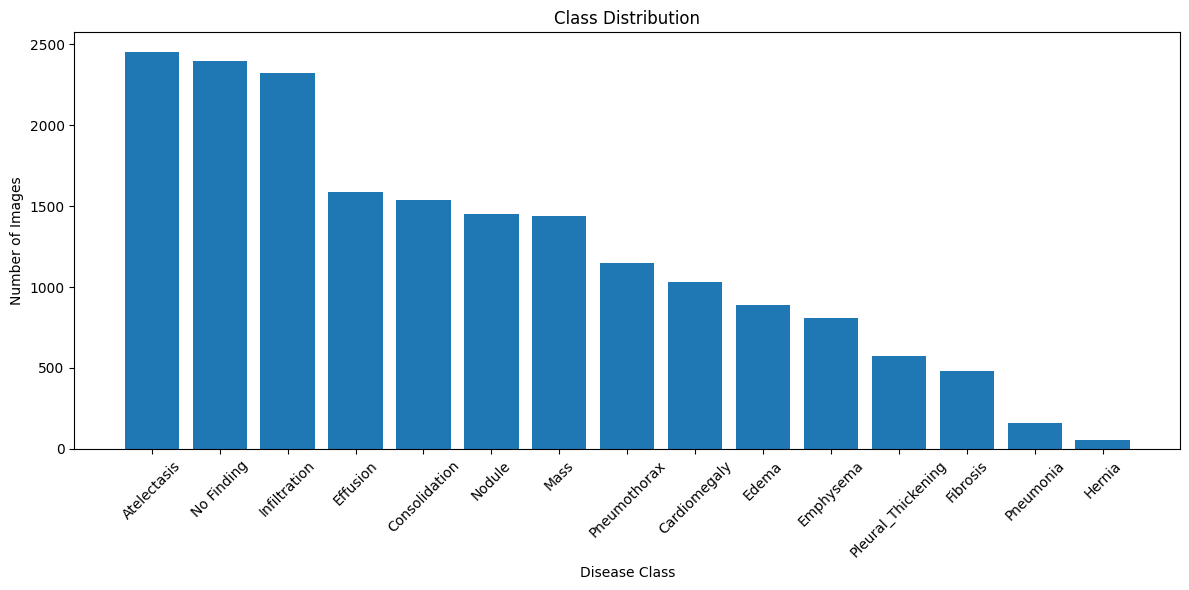

{'Atelectasis': 0, 'Cardiomegaly': 1, 'Consolidation': 2, 'Edema': 3, 'Effusion': 4, 'Emphysema': 5, 'Fibrosis': 6, 'Hernia': 7, 'Infiltration': 8, 'Mass': 9, 'No Finding': 10, 'Nodule': 11, 'Pleural_Thickening': 12, 'Pneumonia': 13, 'Pneumothorax': 14}
[2452, 1032, 1536, 890, 1586, 808, 480, 57, 2323, 1442, 2399, 1449, 574, 162, 1146]
Class Weights: tensor([ 0.4985,  1.1845,  0.7958,  1.3735,  0.7707,  1.5129,  2.5467, 21.4456,
         0.5262,  0.8477,  0.5095,  0.8436,  2.1296,  7.5457,  1.0667])
========== Expanded Dataset Details ==========
Original Split Train Images : 18336
Multiplier Factor (k)       : 0
Final Augmented Train Images: 18336
Validation Images           : 4585


In [6]:
class DatasetMultiplier(Dataset):
    """
    Wraps a PyTorch Subset or Dataset to multiply its length by a factor of (k + 1).
    """
    def __init__(self, base_dataset, k=1):
        self.base_dataset = base_dataset
        self.k = k
        self.base_len = len(base_dataset)

    def __len__(self):
        return self.base_len * (self.k + 1)

    def __getitem__(self, idx):
        # Map the expanded index back into the actual base subset index boundaries
        actual_idx = idx % self.base_len
        return self.base_dataset[actual_idx]

# dataset的建立用來訓練讀檔的

# 先建立 base_dataset，用來讀取所有圖片路徑與 label
# 這裡 transform=None，因為只是用來取得 label 和 class 資訊
base_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=None
)
# 取得每張圖片的 label
targets = np.array(base_dataset.targets)

# 建立所有圖片的 index
indices = np.arange(len(base_dataset))

# 將 train 資料切成 train / validation
# stratify=targets 代表切分時盡量維持每個類別的比例
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=targets
)

# train_full 使用 train_transform
# 這裡會套用資料增強和影像預處理
train_full = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

# val_full 使用 val_test_transform
# validation 不使用隨機資料增強，只做固定預處理
val_full = datasets.ImageFolder(
    root=train_dir,
    transform=val_test_transform
)

# Create the actual base train and validation subsets
base_train_dataset = Subset(train_full, train_idx)
val_dataset = Subset(val_full, val_idx)

# Expand the training dataset by k
K_EXPANSION = 0  # k=1 doubles dataset size, k=2 triples it, etc.
train_dataset = DatasetMultiplier(base_train_dataset, k=K_EXPANSION)

# Re-establish DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = calculate_class_weights_new(base_dataset, base_train_dataset).to(device)

print("========== Expanded Dataset Details ==========")
print("Original Split Train Images :", len(base_train_dataset))
print(f"Multiplier Factor (k)       : {K_EXPANSION}")
print("Final Augmented Train Images:", len(train_dataset)) # Will print 36672 if k=1
print("Validation Images           :", len(val_dataset))

In [7]:
# 1. Device Configuration (Utilize GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Model Definition (ResNet50)
# Pretrained weights provide a robust feature extraction foundation for chest X-rays
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Modify the final fully connected layer to output the correct number of classes (15)
# Add a Dropout layer before the final fully connected layer to prevent co-adaptation of features
num_classes = len(base_dataset.classes) 
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, num_classes)
)
model = model.to(device)

# 3. Loss Function & Optimization Configuration
# criterion = nn.CrossEntropyLoss().to(device)
# test 2 weighted cross entropy
print("Loss Function: Weighted Cross Entropy", f"with class weights: {class_weights.cpu().numpy()}")
criterion = nn.CrossEntropyLoss(weight=class_weights).to(device)
# test 3 focal loss
#print("Loss Function: Focal Loss", f"with class weights: {class_weights.cpu().numpy()} and gamma=2.0")
#criterion = FocalLoss(alpha=class_weights, gamma=2.0, reduction='mean').to(device)
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print(f"Model successfully loaded. Class count: {num_classes}")

Using device: cuda
Loss Function: Weighted Cross Entropy with class weights: [ 0.49853182  1.184496    0.79583335  1.3734832   0.770744    1.5128714
  2.5466666  21.445614    0.5262161   0.8477115   0.5095456   0.8436163
  2.1296167   7.545679    1.0666667 ]
Model successfully loaded. Class count: 15


In [ ]:
# 4. Training and Validation Process
num_epochs = 20
best_val_acc = 0.0
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    train_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Training")
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
        train_bar.set_postfix(loss=loss.item())
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # Step the learning rate scheduler
    scheduler.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}] Results:")
    print(f"  Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}%")
    print(f"  Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")
    
    # Checkpoint evaluation & saving the best model weights
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), "best_resnet50.pth")
        print("  => New best validation accuracy! Saved model weights.")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')  
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("training_validation_curves.png")


print(f"\nTraining completed. Highest Validation Accuracy achieved: {best_val_acc*100:.2f}%")

Epoch [1/20] Training:   1%|▏         | 17/1146 [00:04<04:43,  3.98it/s, loss=2.77]

In [ ]:
# 5. Custom Test Dataset Loader Implementation
class XRayTestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.test_dir = test_dir
        self.transform = transform
        files = os.listdir(test_dir)
        
        # Sort files numerically (0.jpg, 1.jpg...) to maintain sequential structural consistency
        try:
            self.filenames = sorted(files, key=lambda x: int(os.path.splitext(x)[0]))
        except ValueError:
            self.filenames = sorted(files)

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]
        img_path = os.path.join(self.test_dir, filename)
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, filename

# Instantiate Test DataLoader
test_dataset = XRayTestDataset(test_dir=test_dir, transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

# Load the best-saved model checkpoint parameters
model.load_state_dict(torch.load("best_resnet50.pth"))
model.eval()

submission_data = []
class_names = base_dataset.classes # Pull string mapping directly from ImageFolder classes

# --- Inference / Prediction Generation Phase ---
print("Starting testing inference on test set files...")
with torch.no_grad():
    for images, filenames in tqdm(test_loader, desc="Testing Inference"):
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        for i in range(len(filenames)):
            filename = filenames[i]
            pred_class_idx = predicted[i].item()
            pred_class_name = class_names[pred_class_idx]
            
            # Formulate tracking index match format
            row_id = len(submission_data)
            submission_data.append({
                "id": row_id,
                "filename": filename,
                "label": pred_class_name
            })

# 6. Structuring into DataFrame and Exporting Target File
submission_df = pd.DataFrame(submission_data)
submission_df.to_csv("submission.csv", index=False)
print("Submission file generation successfully concluded. Output saved as 'submission.csv'!")

Starting testing inference on test set files...


Testing Inference: 100%|██████████| 313/313 [01:36<00:00,  3.25it/s]


Submission file generation successfully concluded. Output saved as 'submission.csv'!
